# CDMatrix – session MH031

Chargement des données **comme dans les notebooks MH** (`data_choice`, filtre `SSp-bfd`, exclusion des trials auditifs), puis application de l'analyse **CDMatrix** sur cette session.

In [19]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

def data_choice(path):
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        units_df = nwb.units.to_dataframe()
        trials_df = nwb.trials.to_dataframe()
    return units_df, trials_df

# Même logique que dans les notebooks MH, mais robuste au dossier courant
candidate_paths = [
    "data/myriam/MH031_20250509_102210.nwb",
    os.path.join("data", "MH031_20250509_102210.nwb"),
    os.path.join("data", "myriam", "MH031_20250509_102210.nwb"),
    "MH031_20250509_102210.nwb",
]

path = None
for p in candidate_paths:
    if os.path.exists(p):
        path = p
        break

if path is None:
    raise FileNotFoundError(
        "Fichier NWB introuvable. Chemins testés :\n" + "\n".join(candidate_paths)
    )

print("Fichier utilisé :", path)
units_df, trials_df = data_choice(path)
print("Colonnes trials :", list(trials_df.columns))


Fichier utilisé : data/myriam/MH031_20250509_102210.nwb
Colonnes trials : ['start_time', 'stop_time', 'trial_type', 'perf', 'whisker_stim', 'whisker_stim_amplitude', 'whisker_stim_duration', 'whisker_stim_time', 'auditory_stim', 'auditory_stim_amplitude', 'auditory_stim_frequency', 'auditory_stim_duration', 'auditory_stim_time', 'no_stim', 'no_stim_time', 'stim_onset', 'reward_available', 'response_window_start_time', 'response_window_stop_time', 'lick_flag', 'lick_time', 'abort_window_start_time', 'abort_window_stop_time', 'early_lick', 'context', 'context_background', 'opto_stim', 'opto_grid_ap', 'opto_grid_ml', 'opto_grid_no', 'opto_stim_start_time', 'opto_stim_stop_time', 'opto_stim_amplitude', 'opto_stim_frequency', 'trial_id']


## 1. Construction de `AP_Bin_Matrx` comme dans les notebooks MH

In [20]:

# Filtrer SSp-bfd et exclure les trials auditifs, comme dans les notebooks MH
ssp = units_df[units_df['ccf_parent_acronym'] == 'SSp-bfd']
tr = trials_df[trials_df['auditory_stim'] == 0].copy().reset_index(drop=True)

spike_times = [unit['spike_times'] for _, unit in ssp.iterrows()]
print("Nombre d'unités SSp-bfd :", len(spike_times))
print("Nombre de trials sans auditory :", len(tr))

Bin_size = 0.01
AP_Bin_Resolution = 1.0 / Bin_size
duration = float(trials_df['stop_time'].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)
for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("AP_Bin_Matrx shape :", AP_Bin_Matrx.shape)
print("Total spikes :", int(AP_Bin_Matrx.sum()))


Nombre d'unités SSp-bfd : 25
Nombre de trials sans auditory : 242
AP_Bin_Matrx shape : (25, 303661)
Total spikes : 283518


## 2. Vérification des trials whisker et catch

In [21]:

# Diagnostic des colonnes de trials
stim_mask = tr["whisker_stim"].astype(bool).values
catch_mask = tr["no_stim"].astype(bool).values

amps_stim = sorted([
    float(a) for a in pd.unique(tr.loc[stim_mask, "whisker_stim_amplitude"]) if pd.notna(a)
])

Stim_times_by_amp = {}
for a in amps_stim:
    mask_a = stim_mask & (tr["whisker_stim_amplitude"].values == a)
    times_a = tr.loc[mask_a, "whisker_stim_time"].values.astype(float)
    times_a = times_a[~np.isnan(times_a)]
    Stim_times_by_amp[a] = np.sort(times_a)

Catch_times = tr.loc[catch_mask, "no_stim_time"].values.astype(float)
Catch_times = Catch_times[~np.isnan(Catch_times)]
Catch_times = np.sort(Catch_times)

print("Amplitudes trouvées :", amps_stim)
for a in amps_stim:
    print(f"amp {a} : {len(Stim_times_by_amp[a])} stimuli valides")
print("catch :", len(Catch_times))

print("\nValue counts whisker_stim :")
print(tr["whisker_stim"].value_counts(dropna=False))

print("\nValue counts whisker_stim_amplitude :")
print(tr["whisker_stim_amplitude"].value_counts(dropna=False))

print("\nNombre de whisker_stim_time non-NaN parmi whisker_stim==1 :")
print(tr.loc[stim_mask, "whisker_stim_time"].notna().sum())

valid_amps = [a for a in amps_stim if len(Stim_times_by_amp[a]) > 0]
if len(valid_amps) == 0:
    raise ValueError(
        "Aucun stimulus whisker valide trouvé dans whisker_stim_time. "
        "Il faut probablement vérifier la structure des trials de cette session."
    )

ref_amp = max(valid_amps)
Stim_times_ref = Stim_times_by_amp[ref_amp]

print(f"\nAmplitude de référence choisie automatiquement pour la CD : {ref_amp}")
print(f"Nombre de stimuli de référence : {len(Stim_times_ref)}")


Amplitudes trouvées : [3.2, 3.4]
amp 3.2 : 105 stimuli valides
amp 3.4 : 67 stimuli valides
catch : 70

Value counts whisker_stim :
whisker_stim
1    172
0     70
Name: count, dtype: int64

Value counts whisker_stim_amplitude :
whisker_stim_amplitude
3.2    105
0.0     70
3.4     67
Name: count, dtype: int64

Nombre de whisker_stim_time non-NaN parmi whisker_stim==1 :
172

Amplitude de référence choisie automatiquement pour la CD : 3.4
Nombre de stimuli de référence : 67


## 3. PSTH population : amplitude de référence vs catch

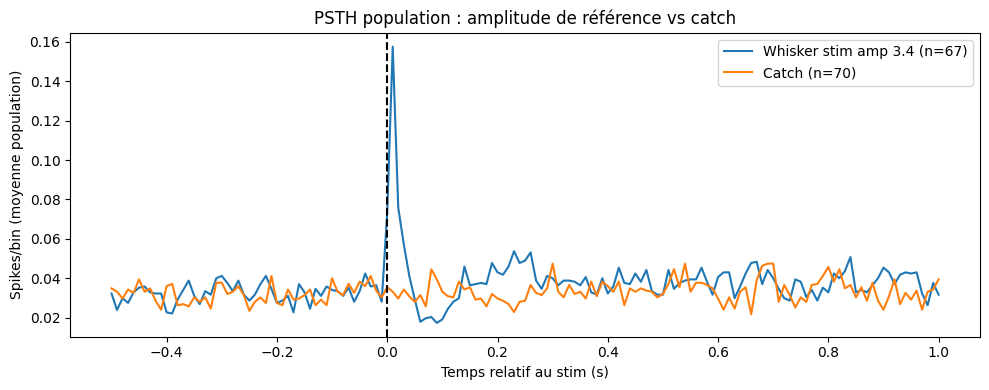

In [22]:

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)

def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

STM_MTRX, n_stim = event_triggered_mean(AP_Bin_Matrx, Stim_times_ref, AP_Bin_Resolution, pre_bins, post_bins)
CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure(figsize=(10, 4))
plt.plot(time_axis, STM_MTRX.mean(axis=0), label=f"Whisker stim amp {ref_amp} (n={n_stim})")
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--", color="k")
plt.xlabel("Temps relatif au stim (s)")
plt.ylabel("Spikes/bin (moyenne population)")
plt.title("PSTH population : amplitude de référence vs catch")
plt.legend()
plt.tight_layout()
plt.show()


## 4. CDMatrix : deux fenêtres temporelles

In [23]:

win1 = (0, 8)      # premier pic (~0–30 ms)
win2 = (23, 31)     # second pic (~80–180 ms)
pre_baseline = 10

def extract_two_window_matrix(AP, event_time, resolution, win1, win2, pre_baseline):
    pt = int(np.round(event_time * resolution))

    if pt - pre_baseline < 0 or pt + win2[1] >= AP.shape[1]:
        return None

    seg1 = AP[:, pt + win1[0]: pt + win1[1]]
    seg2 = AP[:, pt + win2[0]: pt + win2[1]]

    if seg1.shape[1] == 0 or seg2.shape[1] == 0:
        return None

    mat = np.concatenate([seg1, seg2], axis=1)

    baseline = AP[:, pt - pre_baseline: pt].mean(axis=1, keepdims=True)
    mat = mat - baseline

    return mat

def build_stack(AP, times, resolution, win1, win2, pre_baseline):
    mats = []
    kept_times = []

    for t in times:
        m = extract_two_window_matrix(AP, t, resolution, win1, win2, pre_baseline)
        if m is not None:
            mats.append(m)
            kept_times.append(t)

    if len(mats) == 0:
        return None, np.array([])

    return np.array(mats), np.array(kept_times)

def flatten(mat):
    return mat.reshape(-1).astype(np.float32)

def zscore_vector(v, eps=1e-10):
    v = np.asarray(v, dtype=np.float32)
    mu = np.mean(v)
    sd = np.std(v)
    return (v - mu) / (sd + eps)

def euclidean(v1, v2):
    return np.linalg.norm(v1 - v2)

def cosine(v1, v2):
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-10
    return np.dot(v1, v2) / denom

def score_stack_against_reference(stack, ref_vector, normalize=True):
    if stack is None or len(stack) == 0:
        return np.array([]), np.array([])

    distances = []
    cosines = []

    for mat in stack:
        vec = flatten(mat)
        if normalize:
            vec = vec
            ref = ref_vector
        else:
            ref = ref_vector

        distances.append(euclidean(vec, ref))
        cosines.append(cosine(vec, ref))

    return np.array(distances), np.array(cosines)


In [24]:
from sklearn.model_selection import train_test_split

# split des stimuli de référence
Stim_times_all = Stim_times_by_amp[ref_amp]

Stim_train, Stim_test = train_test_split(
    Stim_times_all,
    test_size=0.5,
    random_state=42
)

# stacks
stim_train_stack, _ = build_stack(
    AP_Bin_Matrx, Stim_train, AP_Bin_Resolution, win1, win2, pre_baseline
)

stim_test_stack, _ = build_stack(
    AP_Bin_Matrx, Stim_test, AP_Bin_Resolution, win1, win2, pre_baseline
)

catch_stack, _ = build_stack(
    AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, win1, win2, pre_baseline
)

# CD uniquement sur TRAIN
mean_stim = stim_train_stack.mean(axis=0)
mean_catch = catch_stack.mean(axis=0)

CD_matrix = mean_stim - mean_catch
CD_vector = zscore_vector(flatten(CD_matrix))

print("stim_stack shape :", stim_train_stack.shape)
print("catch_stack shape :", catch_stack.shape)
print("CD_matrix shape :", CD_matrix.shape)
print("CD_vector shape :", CD_vector.shape)


stim_stack shape : (33, 25, 16)
catch_stack shape : (70, 25, 16)
CD_matrix shape : (25, 16)
CD_vector shape : (400,)


## 5. Score CD sur le signal continu

In [25]:

valid_t = []
distances = []
cosines = []

T = AP_Bin_Matrx.shape[1]

step = 3
for pt in range(pre_baseline, T - win2[1], step):
    event_time = pt / AP_Bin_Resolution

    mat = extract_two_window_matrix(
        AP_Bin_Matrx,
        event_time,
        AP_Bin_Resolution,
        win1,
        win2,
        pre_baseline
    )

    if mat is None:
        continue

    vec = flatten(mat)
    vec_z = vec

    distances.append(euclidean(vec_z, CD_vector))
    cosines.append(cosine(vec_z, CD_vector))
    valid_t.append(pt)

valid_t = np.array(valid_t)
t_cont = valid_t * Bin_size
distances = np.array(distances)
cosines = np.array(cosines)

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in valid_amps]))

def build_null_stack_from_continuous(AP, AP_Bin_Resolution, win1, win2, pre_baseline,
                                     stim_times, exclusion_s=0.5, step_bins=20, max_samples=500):
    """
    Construit un stack de fenêtres 'null' prises dans le signal continu,
    loin de tout stimulus connu.
    """
    T = AP.shape[1]
    valid_times = []

    # temps continus possibles
    for pt in range(pre_baseline, T - win2[1], step_bins):
        t = pt / AP_Bin_Resolution

        # exclure les temps trop proches d'un stimulus
        if np.any(np.abs(stim_times - t) < exclusion_s):
            continue

        valid_times.append(t)

    valid_times = np.array(valid_times)

    # sous-échantillonnage si trop de points
    if len(valid_times) > max_samples:
        rng = np.random.default_rng(42)
        valid_times = np.sort(rng.choice(valid_times, size=max_samples, replace=False))

    null_stack, kept = build_stack(
        AP, valid_times, AP_Bin_Resolution, win1, win2, pre_baseline
    )

    return null_stack, kept

null_stack, null_times = build_null_stack_from_continuous(
    AP_Bin_Matrx,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline,
    all_stim_times,
    exclusion_s=0.5,
    step_bins=20,
    max_samples=500
)

d_null, c_null = score_stack_against_reference(
    null_stack, CD_vector, normalize=True
)

thr_dist = np.mean(d_null) - 3.0 * np.std(d_null)
thr_cos  = np.mean(c_null) + 3.0 * np.std(c_null)

print("Nb null windows :", len(d_null))
print("Seuil distance :", thr_dist)
print("Seuil cosine :", thr_cos)
print("Nombre total de stimuli valides :", len(all_stim_times))



Nb null windows : 500
Seuil distance : 19.23210698366165
Seuil cosine : 0.21806981217515314
Nombre total de stimuli valides : 172


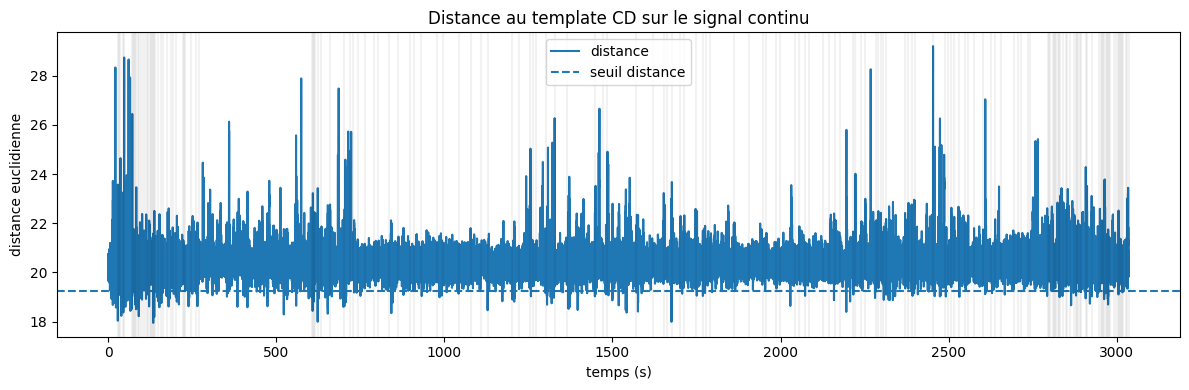

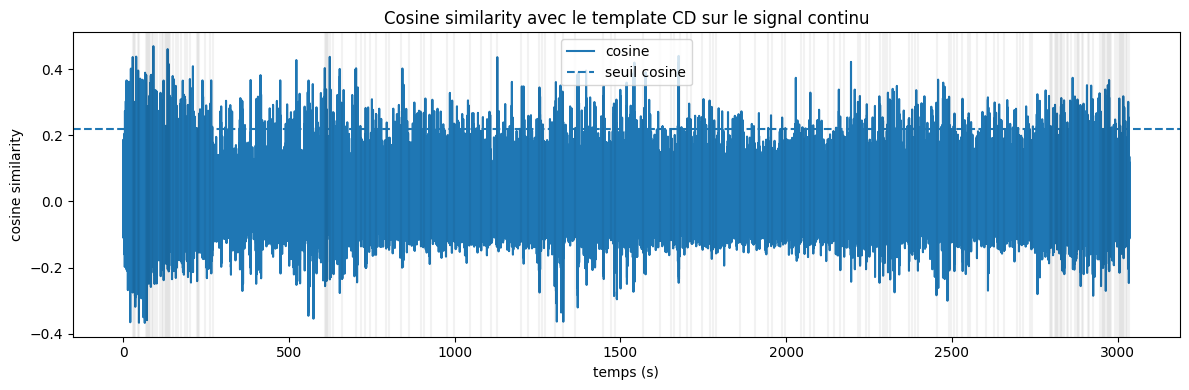

In [26]:

plt.figure(figsize=(12, 4))
plt.plot(t_cont, distances, label="distance")
plt.axhline(thr_dist, linestyle="--", label="seuil distance")
for ts in all_stim_times:
    plt.axvline(ts, color="k", alpha=0.05)
plt.xlabel("temps (s)")
plt.ylabel("distance euclidienne")
plt.title("Distance au template CD sur le signal continu")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_cont, cosines, label="cosine")
plt.axhline(thr_cos, linestyle="--", label="seuil cosine")
for ts in all_stim_times:
    plt.axvline(ts, color="k", alpha=0.05)
plt.xlabel("temps (s)")
plt.ylabel("cosine similarity")
plt.title("Cosine similarity avec le template CD sur le signal continu")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Détection des événements ressemblant à la CD

In [27]:

from scipy.signal import find_peaks

def detect_local_extrema(values, times, threshold, mode="high",
                         refractory_s=0.3, prominence=None):
    values = np.asarray(values)
    times = np.asarray(times)

    if len(values) == 0:
        return np.array([]), np.array([], dtype=int)

    dt = np.median(np.diff(times)) if len(times) > 1 else 0.01
    min_distance_bins = max(1, int(np.round(refractory_s / dt)))

    if prominence is None:
        prominence = 0.5 * np.std(values)

    if mode == "high":
        idx, _ = find_peaks(
            values,
            height=threshold,
            distance=min_distance_bins,
            prominence=prominence
        )
    elif mode == "low":
        idx, _ = find_peaks(
            -values,
            height=-threshold,
            distance=min_distance_bins,
            prominence=prominence
        )
    else:
        raise ValueError("mode doit être 'high' ou 'low'")

    return times[idx], idx

refractory_s = 0.4
tol_match = 0.1

detected_cos, detected_cos_idx = detect_local_extrema(
    cosines, t_cont,
    threshold=thr_cos,
    mode="high",
    refractory_s=refractory_s,
    prominence=0.5 * np.std(cosines)
)

detected_dist, detected_dist_idx = detect_local_extrema(
    distances, t_cont,
    threshold=thr_dist,
    mode="low",
    refractory_s=refractory_s,
    prominence=0.5 * np.std(distances)
)

print("Détections cosine :", len(detected_cos))
print("Détections distance :", len(detected_dist))


Détections cosine : 704
Détections distance : 226


In [28]:

def match_rate(detected, true_times, tol=0.1):
    if len(true_times) == 0:
        return np.nan
    TP = 0
    for t in true_times:
        if np.any(np.abs(detected - t) < tol):
            TP += 1
    return TP / len(true_times)

for a in valid_amps:
    print(
        f"amp {a} | dist={match_rate(detected_dist, Stim_times_by_amp[a], tol_match):.2f} "
        f"| cos={match_rate(detected_cos, Stim_times_by_amp[a], tol_match):.2f}"
    )


amp 3.2 | dist=0.10 | cos=0.27
amp 3.4 | dist=0.22 | cos=0.27


In [29]:
def compute_precision(detected_times, true_times, tolerance=0.1):
    TP = 0
    
    for t in detected_times:
        if np.any(np.abs(true_times - t) < tolerance):
            TP += 1
    
    precision = TP / len(detected_times) if len(detected_times) > 0 else 0
    return precision

prec_dist = compute_precision(detected_dist, all_stim_times)
prec_cos  = compute_precision(detected_cos, all_stim_times)

print("Precision distance:", prec_dist)
print("Precision cosine:", prec_cos)

Precision distance: 0.11061946902654868
Precision cosine: 0.06534090909090909


## 7. Comparaison vrais stimuli vs détections spontanées

In [30]:

def classify_detected_events(detected, true_times, tol=0.1):
    detected = np.asarray(detected)
    true_times = np.asarray(true_times)

    is_true = np.array([
        np.any(np.abs(t - true_times) < tol) for t in detected
    ], dtype=bool)

    return detected[is_true], detected[~is_true]

stim_detected_cos, spont_detected_cos = classify_detected_events(detected_cos, all_stim_times, tol_match)
stim_detected_dist, spont_detected_dist = classify_detected_events(detected_dist, all_stim_times, tol_match)

print("Cosine  -> proches d'un vrai stim :", len(stim_detected_cos))
print("Cosine  -> spontanés :", len(spont_detected_cos))
print("Distance -> proches d'un vrai stim :", len(stim_detected_dist))
print("Distance -> spontanés :", len(spont_detected_dist))

true_stim_stack, true_stim_kept = build_stack(
    AP_Bin_Matrx, all_stim_times, AP_Bin_Resolution, win1, win2, pre_baseline
)

spont_cos_stack, spont_cos_kept = build_stack(
    AP_Bin_Matrx, spont_detected_cos, AP_Bin_Resolution, win1, win2, pre_baseline
)

spont_dist_stack, spont_dist_kept = build_stack(
    AP_Bin_Matrx, spont_detected_dist, AP_Bin_Resolution, win1, win2, pre_baseline
)

d_true, c_true = score_stack_against_reference(true_stim_stack, CD_vector)
d_spont_cos, c_spont_cos = score_stack_against_reference(spont_cos_stack, CD_vector)
d_spont_dist, c_spont_dist = score_stack_against_reference(spont_dist_stack, CD_vector)

print("Vrais stimuli gardés :", len(true_stim_kept))
print("Spontanés cosine gardés :", len(spont_cos_kept))
print("Spontanés distance gardés :", len(spont_dist_kept))


Cosine  -> proches d'un vrai stim : 46
Cosine  -> spontanés : 658
Distance -> proches d'un vrai stim : 25
Distance -> spontanés : 201
Vrais stimuli gardés : 172
Spontanés cosine gardés : 658
Spontanés distance gardés : 201


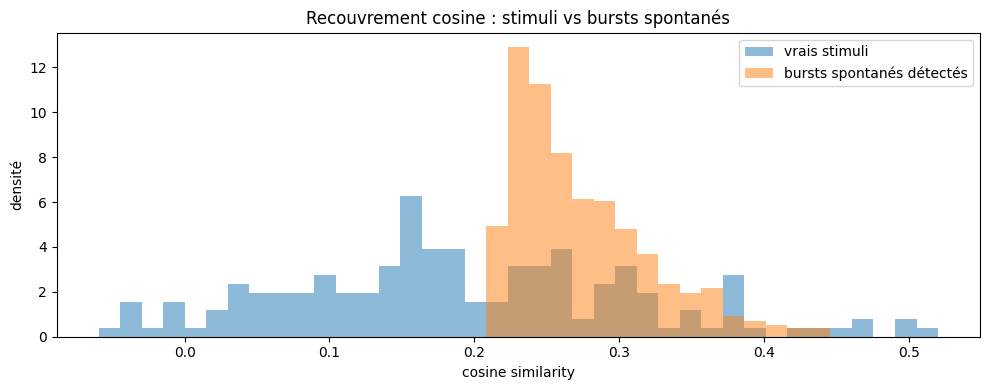

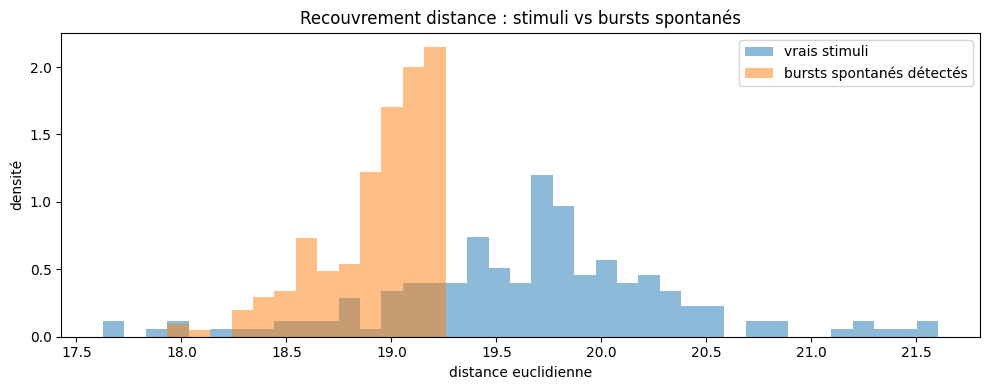

In [31]:

if len(c_true) > 0 and len(c_spont_cos) > 0:
    plt.figure(figsize=(10, 4))
    bins_cos = np.linspace(
        min(np.nanmin(c_true), np.nanmin(c_spont_cos)),
        max(np.nanmax(c_true), np.nanmax(c_spont_cos)),
        40
    )
    plt.hist(c_true, bins=bins_cos, alpha=0.5, density=True, label="vrais stimuli")
    plt.hist(c_spont_cos, bins=bins_cos, alpha=0.5, density=True, label="bursts spontanés détectés")
    plt.xlabel("cosine similarity")
    plt.ylabel("densité")
    plt.title("Recouvrement cosine : stimuli vs bursts spontanés")
    plt.legend()
    plt.tight_layout()
    plt.show()

if len(d_true) > 0 and len(d_spont_dist) > 0:
    plt.figure(figsize=(10, 4))
    bins_dist = np.linspace(
        min(np.nanmin(d_true), np.nanmin(d_spont_dist)),
        max(np.nanmax(d_true), np.nanmax(d_spont_dist)),
        40
    )
    plt.hist(d_true, bins=bins_dist, alpha=0.5, density=True, label="vrais stimuli")
    plt.hist(d_spont_dist, bins=bins_dist, alpha=0.5, density=True, label="bursts spontanés détectés")
    plt.xlabel("distance euclidienne")
    plt.ylabel("densité")
    plt.title("Recouvrement distance : stimuli vs bursts spontanés")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [32]:
def evaluate_windows(win1, win2, AP_Bin_Matrx, Stim_times, Catch_times):
    
    stim_stack, _ = build_stack(
        AP_Bin_Matrx, Stim_times, AP_Bin_Resolution,
        win1, win2, pre_baseline
    )
    
    catch_stack, _ = build_stack(
        AP_Bin_Matrx, Catch_times, AP_Bin_Resolution,
        win1, win2, pre_baseline
    )
    
    if stim_stack is None or catch_stack is None:
        return None
    
    # CD
    CD_matrix = stim_stack.mean(axis=0) - catch_stack.mean(axis=0)
    CD_vector = zscore_vector(flatten(CD_matrix))
    
    # scores
    d_stim, _ = score_stack_against_reference(stim_stack, CD_vector, normalize=True)
    d_catch, _ = score_stack_against_reference(catch_stack, CD_vector, normalize=True)
    
    score = np.mean(d_catch) - np.mean(d_stim)
    
    return score


results = []

# paramètres à ajuster
win_starts = range(0, 10)   # 0 → 100 ms
win_sizes = [2, 3, 5, 8]   # tailles de fenêtre

Stim_times = Stim_train

for w1_start in win_starts:
    for w1_size in win_sizes:
        win1 = (w1_start, w1_start + w1_size)
        
        for w2_start in range(w1_start + w1_size + 2, 30):
            for w2_size in win_sizes:
                
                win2 = (w2_start, w2_start + w2_size)
                
                score = evaluate_windows(
                    win1, win2,
                    AP_Bin_Matrx,
                    Stim_times,
                    Catch_times
                )
                
                if score is not None:
                    results.append((score, win1, win2))

In [33]:
results_sorted = sorted(results, key=lambda x: x[0], reverse=True)

top_k = 5

print("Top windows :\n")

for i in range(top_k):
    score, w1, w2 = results_sorted[i]
    print(f"{i+1}. score={score:.4f} | win1={w1} | win2={w2}")
    
scores = [r[0] for r in results]


Top windows :

1. score=1.3256 | win1=(0, 8) | win2=(23, 31)
2. score=1.3114 | win1=(1, 9) | win2=(23, 31)
3. score=1.2983 | win1=(0, 8) | win2=(22, 30)
4. score=1.2859 | win1=(1, 9) | win2=(22, 30)
5. score=1.2842 | win1=(0, 8) | win2=(24, 32)


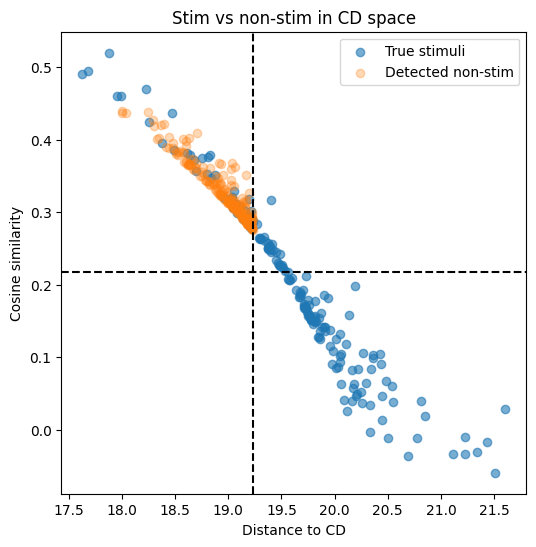

In [34]:
plt.figure(figsize=(6,6))

# vrais stimuli
plt.scatter(d_true, c_true, alpha=0.6, label="True stimuli")

# non alignés (pseudo spontanés)
plt.scatter(d_spont_dist, c_spont_dist, alpha=0.3, label="Detected non-stim")

# seuils
plt.axvline(thr_dist, linestyle='--', color='black')
plt.axhline(thr_cos, linestyle='--', color='black')

plt.xlabel("Distance to CD")
plt.ylabel("Cosine similarity")
plt.title("Stim vs non-stim in CD space")
plt.legend()
plt.show()

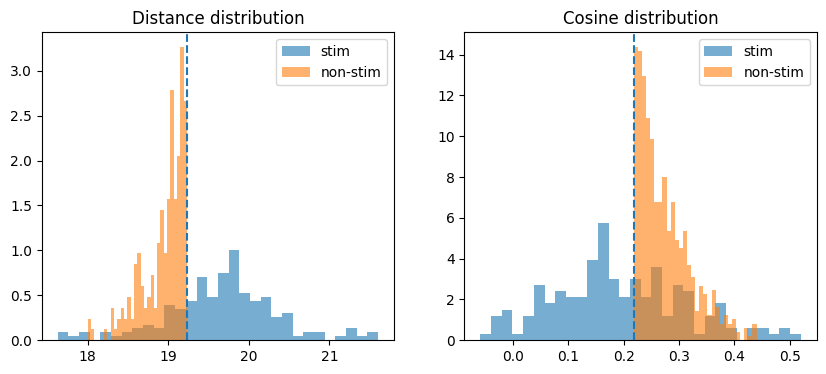

In [35]:
plt.figure(figsize=(10,4))

# distance
plt.subplot(1,2,1)
plt.hist(d_true, bins=30, alpha=0.6, density=True, label="stim")
plt.hist(d_spont_dist, bins=30, alpha=0.6, density=True, label="non-stim")
plt.axvline(thr_dist, linestyle='--')
plt.title("Distance distribution")
plt.legend()

# cosine
plt.subplot(1,2,2)
plt.hist(c_true, bins=30, alpha=0.6, density=True, label="stim")
plt.hist(c_spont_cos, bins=30, alpha=0.6, density=True, label="non-stim")
plt.axvline(thr_cos, linestyle='--')
plt.title("Cosine distribution")
plt.legend()

plt.show()